Este proyecto fue realizado con datos de Kaggle sobre las ventas de la tienda Rossman en el cual intentaremos predecir ventas ocupando el modelo Propthet de Facebook

In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.
Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv('train.csv', low_memory=False)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Trazaremos las ventas de la tienda 1

<Axes: title={'center': 'Store 1 Sales'}>

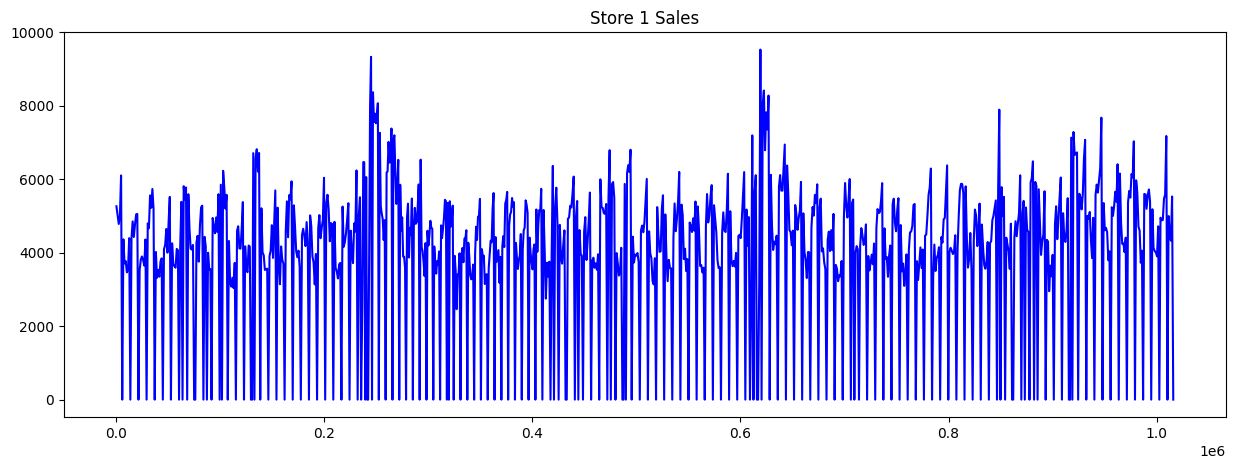

In [3]:
df[df['Store'] == 1]['Sales'].plot(figsize=(15, 5), title='Store 1 Sales', color='blue')

Vemos un comportamiento con estacionalidades y algunos puntos que se van a 0, por lo tanto veremos cuantos valores se van a 0

In [4]:
(df[df['Store'] == 1]['Sales']==0).sum()

np.int64(161)

Seleccionaremos los datos solo de la tienda 1

In [5]:
store1 = df[df['Store'] == 1].copy()

Probablemente se van a 0 las ventas porque esos dias la tienda no esta abierta, por lo cual graficaremos las ventas solo de los días que la tienda esta abierta

<Axes: title={'center': 'Store 1 Sales'}>

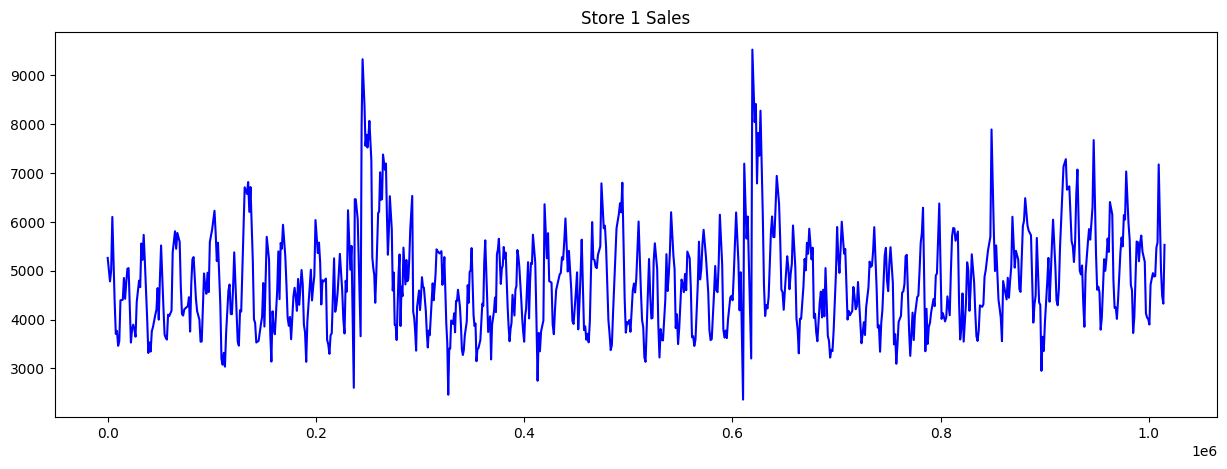

In [6]:
store1[store1['Open'] > 0]['Sales'].plot(figsize=(15, 5), title='Store 1 Sales', color='blue')

Hay varias formas de comprobar donde las ventas son 0

In [7]:
sales0 = store1[store1['Sales'] == 0].index
customers0 = store1[store1['Customers'] == 0].index
store_closed = store1[store1['Open'] == 0].index
print(np.all(sales0 == customers0))
print(np.all(store_closed == customers0))

True
True


In [8]:
store1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1115,1,4,2015-07-30,5020,546,1,1,0,1
2230,1,3,2015-07-29,4782,523,1,1,0,1
3345,1,2,2015-07-28,5011,560,1,1,0,1
4460,1,1,2015-07-27,6102,612,1,1,0,1


Convertimos la fecha a formato fecha

In [9]:
store1['Date'] = pd.to_datetime(store1['Date'])

Ahora establecemos las fechas como indice, solo para verlo de forma grafica, ya que para el modelo de prophet necesitamos la fecha como columna

In [10]:
store1.set_index('Date', inplace=True)

In [11]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


<Axes: title={'center': 'Store 1 Sales'}, xlabel='Date'>

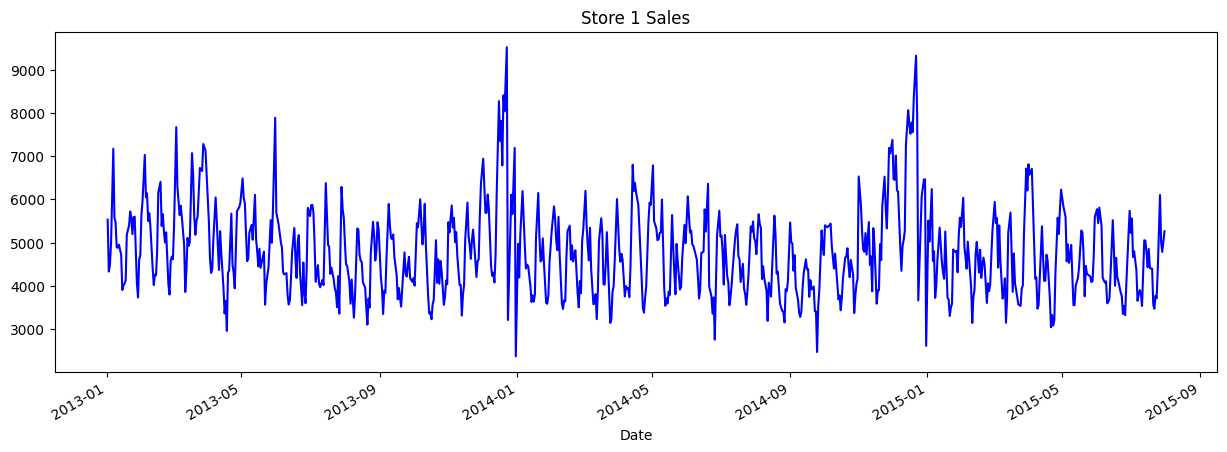

In [12]:
store1[store1['Customers'] > 0]['Sales'].plot(figsize=(15, 5), title='Store 1 Sales', color='blue')

Ahora lo dejaremos en el formato que necesitamos para el modelo prophet

In [13]:
df_p = store1[['Sales']].copy()

In [14]:
df_p['Date'] = df_p.index

In [16]:
df_p.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [17]:
df_p.tail()

,Sales,Date
Date,,
2013-01-05,4997,2013-01-05
2013-01-04,4486,2013-01-04
2013-01-03,4327,2013-01-03
2013-01-02,5530,2013-01-02
2013-01-01,0,2013-01-01


In [19]:
df_p.sort_index(inplace=True)

In [20]:
df_p.head()

,Sales,Date
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05


In [21]:
df_p.tail()

,Sales,Date
Date,,
2015-07-27,6102,2015-07-27
2015-07-28,5011,2015-07-28
2015-07-29,4782,2015-07-29
2015-07-30,5020,2015-07-30
2015-07-31,5263,2015-07-31


Cambiamos el nombre de las columnas

In [22]:
df_p.columns = ['y', 'ds']

Llamamos al modelo

In [24]:
m = Prophet()

Entrenamos al modelo con nuestros datos

In [25]:
m.fit(df_p)

16:51:29 - cmdstanpy - INFO - Chain [1] start processing
16:51:29 - cmdstanpy - INFO - Chain [1] done processing


Realizaremos la prediccion con un periodo definido

In [26]:
future = m.make_future_dataframe(periods=365)

In [27]:
future.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [28]:
future.tail()

,ds
1302,2016-07-26
1303,2016-07-27
1304,2016-07-28
1305,2016-07-29
1306,2016-07-30


Ahora realizaremos el pronostico real con las fechas futuras creadas

In [29]:
forecast = m.predict(future)

In [30]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1302,2016-07-26,3747.516680,3032.241243,5932.821510,3716.568765,3776.861067,713.787322,713.787322,713.787322,706.247293,706.247293,706.247293,7.540029,7.540029,7.540029,0.0,0.0,0.0,4461.304002
1303,2016-07-27,3747.320187,2841.489514,5658.823032,3716.307839,3776.826370,503.023234,503.023234,503.023234,510.491956,510.491956,510.491956,-7.468722,-7.468722,-7.468722,0.0,0.0,0.0,4250.343421
1304,2016-07-28,3747.123695,2383.140172,5325.681602,3716.052851,3776.791674,127.148498,127.148498,127.148498,151.257953,151.257953,151.257953,-24.109455,-24.109455,-24.109455,0.0,0.0,0.0,3874.272193
1305,2016-07-29,3746.927202,2838.880619,5867.494822,3715.758562,3776.684780,531.580814,531.580814,531.580814,573.629403,573.629403,573.629403,-42.048589,-42.048589,-42.048589,0.0,0.0,0.0,4278.508016
1306,2016-07-30,3746.730709,3254.753117,6100.016427,3715.464274,3776.518693,938.165053,938.165053,938.165053,999.097003,999.097003,999.097003,-60.931950,-60.931950,-60.931950,0.0,0.0,0.0,4684.895762


Nuestra columna final es la prediccion 'yhat', ahora graficaremos los resultados

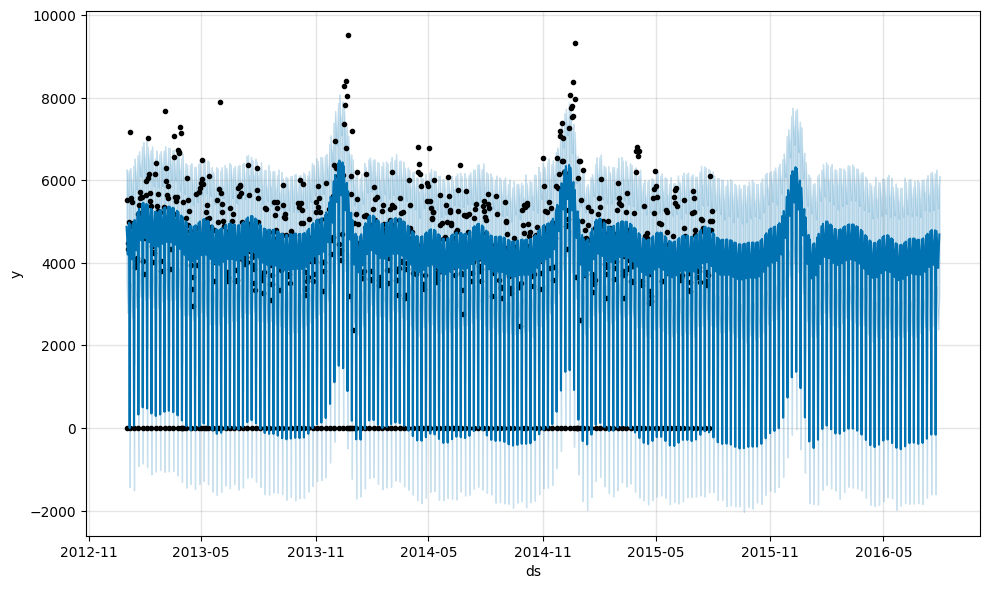

In [34]:
m.plot(forecast);

Nuestros puntos negros son nuestros datos originales, nuestra prediccion del modelo son la linea azul gruesa, los intervalos corresponden a las lineas azul transparente y el periodo del pronostico es lo azul sin puntos negros (El modelo no es capaz de predecir los dias domingos en 0 cuando no abre la tienda)

Ahora graficaremos cada uno de los componentes del modelo

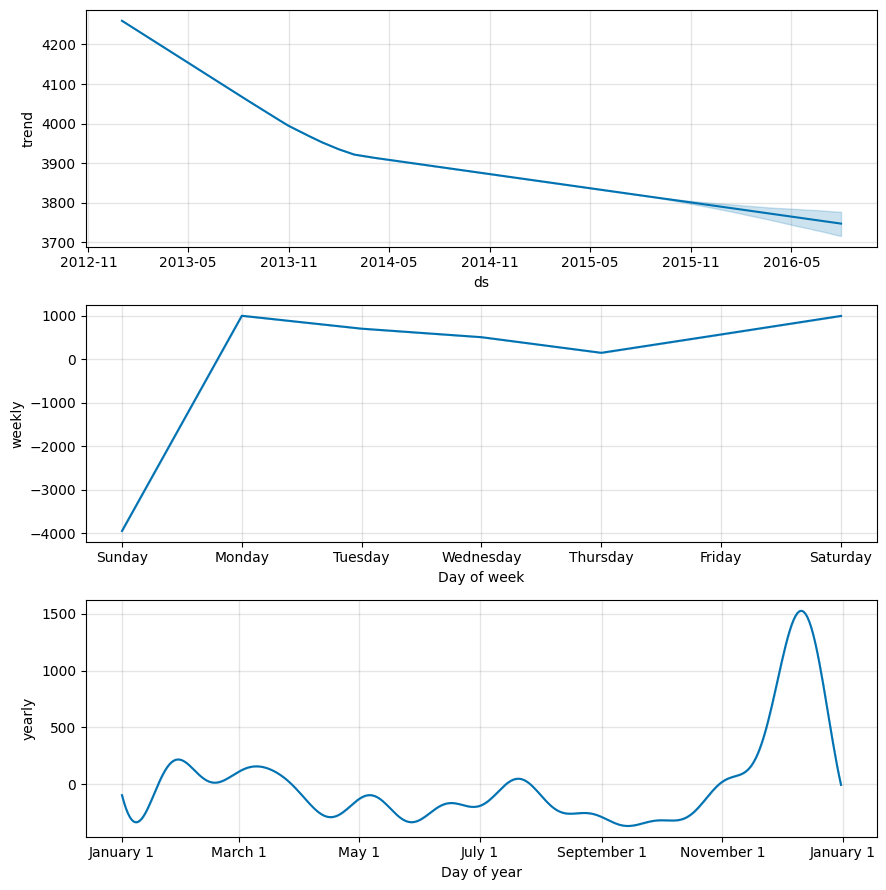

In [33]:
m.plot_components(forecast);

Podemos ver la tendencia en el primer grafico, luego como se comporta en la semana (con los domingos llendose a 0) y por ultimo como se comporta de forma anual, donde en las vacaciones a final de año crecen nuestras ventas

Por lo cual el siguiente paso es construir un modelo unicamente para los dias que la tienda esta abierta ya que sabemos que los domingos cierra.

Model Open Days Only

In [35]:
df_p2 = store1[store1['Open']>0][['Sales']].copy()
df_p2['Date'] = df_p2.index

In [36]:
df_p2.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [39]:
df_p2.columns = ['y', 'ds']

17:10:33 - cmdstanpy - INFO - Chain [1] start processing
17:10:34 - cmdstanpy - INFO - Chain [1] done processing


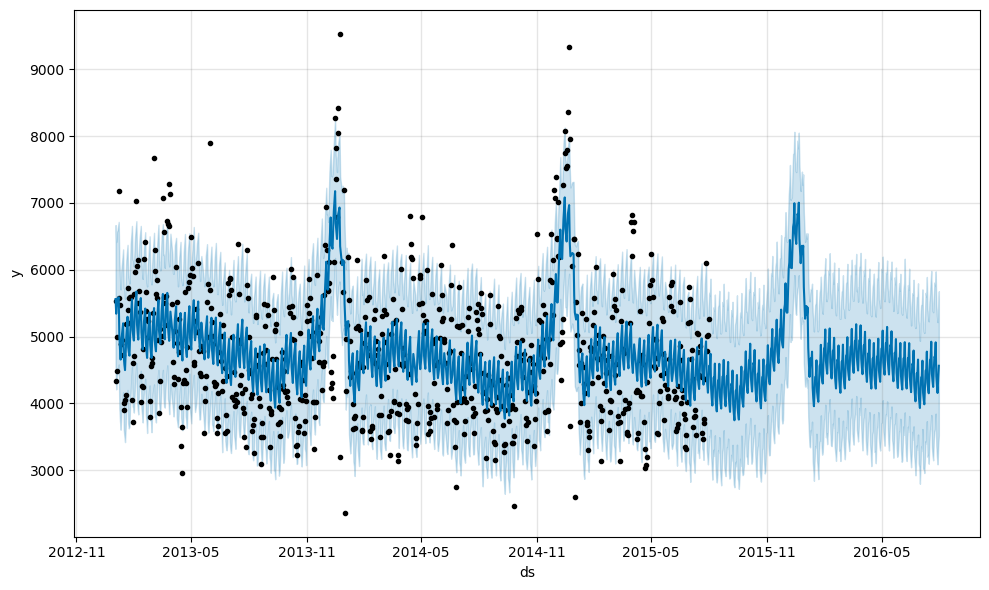

In [40]:
m2 = Prophet()
m2.fit(df_p2)
future2 = m2.make_future_dataframe(periods=365)
forecast2 = m2.predict(future2)
m2.plot(forecast2);

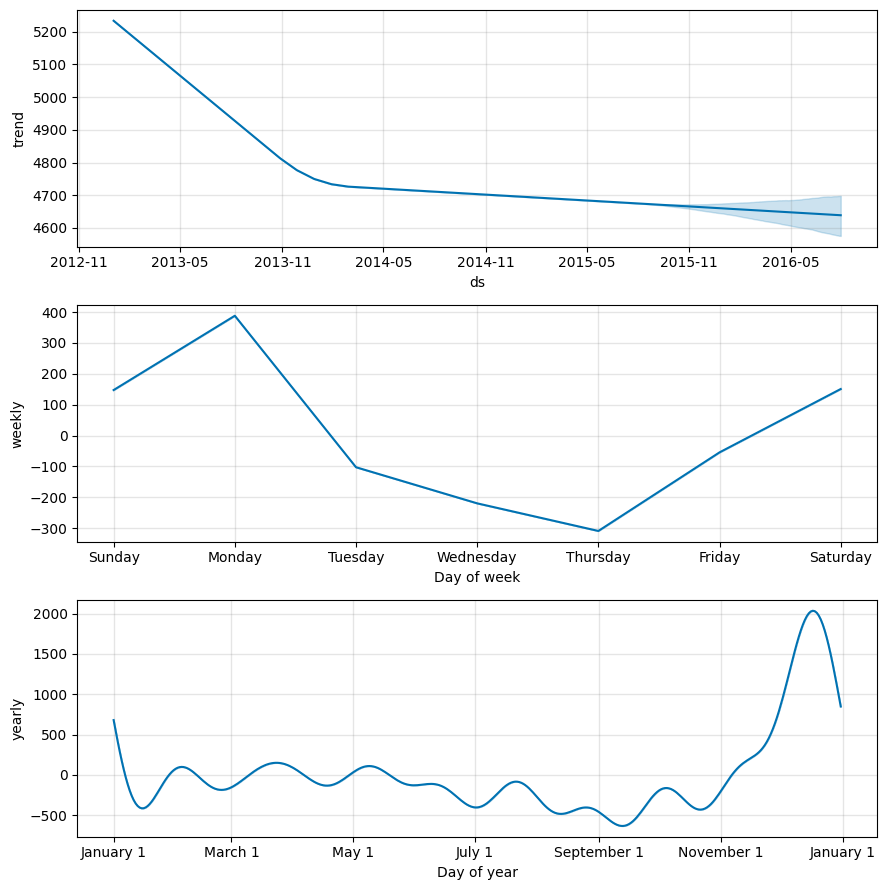

In [41]:
m2.plot_components(forecast2);

Nuestro pronostico parece mucho mas certero ya que no debe modelar los datos en 0 en los dias que a tienda esta cerrada. (Aunque el modelo predice de forma continua, por lo cual como analista deberiamos omitir las ventas de los dias domingos)

Add Holidays

In [51]:
m3 = Prophet()

Incorporamos las vacaciones, en este caso de US

In [ ]:
m3.add_country_holidays(country_name='US')
#m3.add_country_holidays(country_name='CL') En caso de Chile

Lo entrenaremos con los datos que excluimos cuando la tienda estaba cerrada

In [53]:
m3.fit(df_p2)

18:17:01 - cmdstanpy - INFO - Chain [1] start processing
18:17:01 - cmdstanpy - INFO - Chain [1] done processing


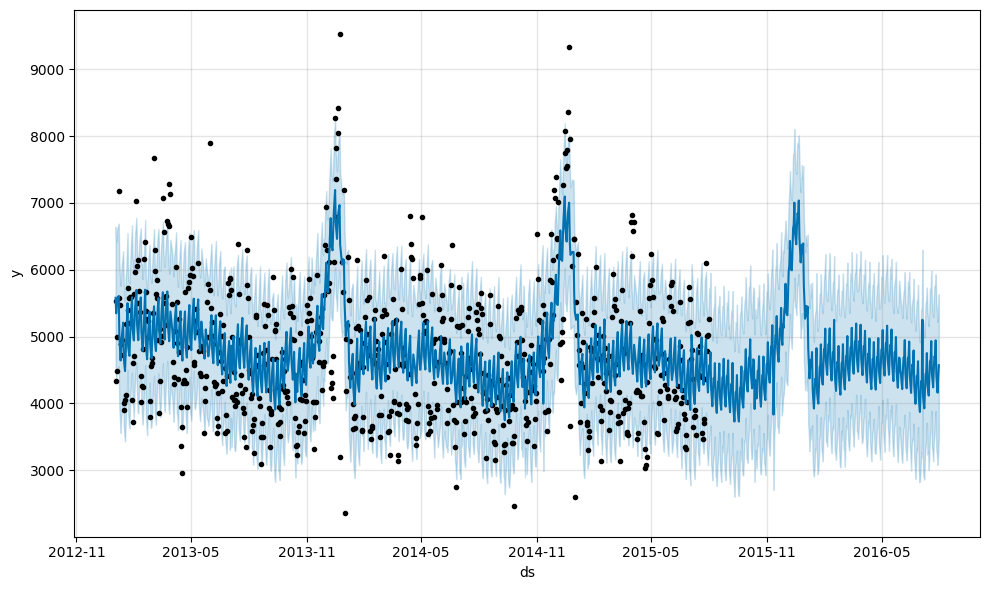

In [54]:
future3 = m3.make_future_dataframe(periods=365)
forecast3 = m3.predict(future3)
m3.plot(forecast3);

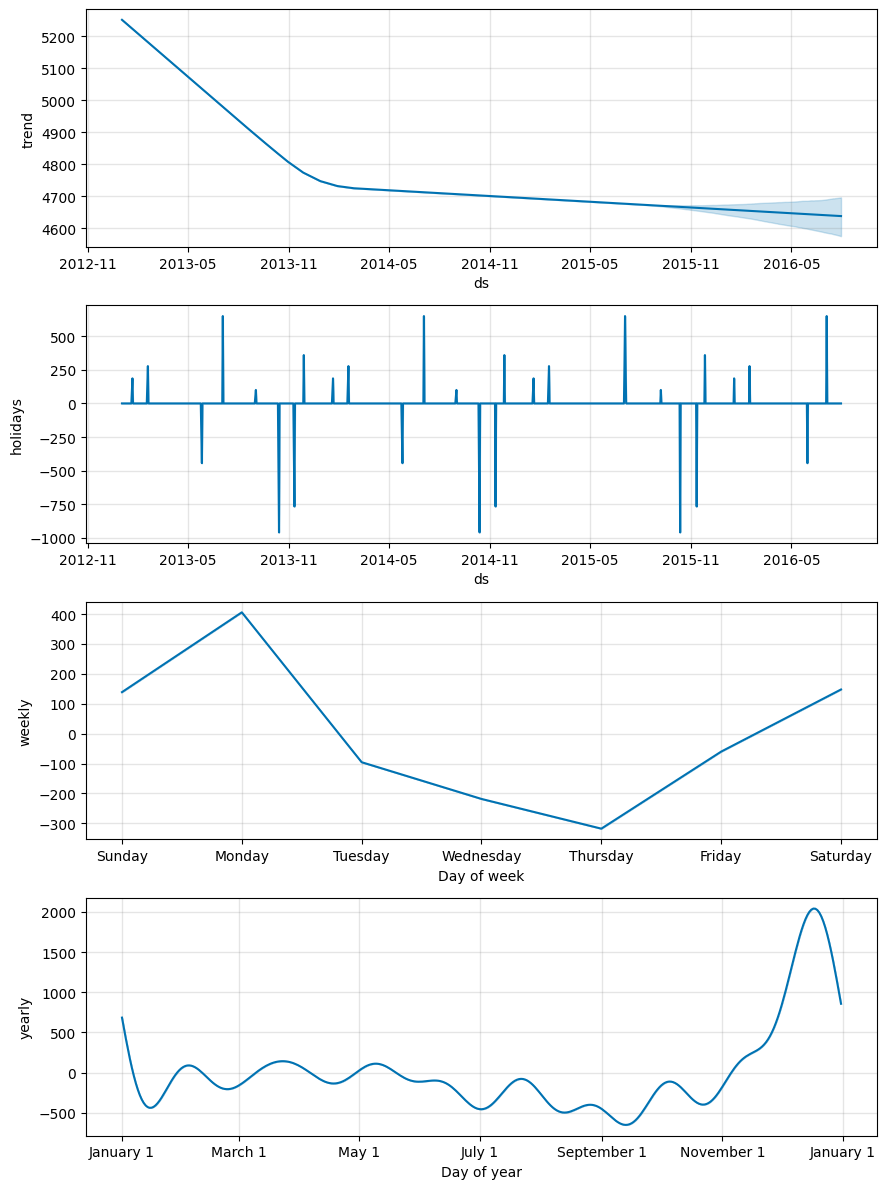

In [55]:
m3.plot_components(forecast3);

Como se puede apreciar hay un componente adicional "Holidays" lo que demuestra la influencia de cada festividad